In [1]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
# sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# import sys
conda_env = sys.path[1]
del sys.path[1]

# sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path.append(home+'/GIGALens-Code/')
print(sys.path)



srcdir = os.path.join(home, "gigalens/src/")

['', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '/usr/local/lib/python3.12/dist-packages', '__editable__.flax-0.10.6.finder.__path_hook__', '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__', '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__', '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__', '/opt/pip/src', '/usr/lib/python3/dist-packages', '/global/homes/l/linusu//gigalens/src', '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages', '/global/homes/l/linusu//GIGALens-Code/']


In [2]:
import jax
import blackjax

import sys

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import BackwardProbModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.model import PhysicalModel
from gigalens.jax.profiles.light import sersic, shapelets, sersic
from gigalens.jax.profiles.mass import epl, shear

import corner as corner
import tensorflow_probability.substrates.jax as tfp
from jax import numpy as jnp
import time
import numpy as np
import optax
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm, kstest
from astropy.visualization import simple_norm
tfd = tfp.distributions

import blackjax
# from gigalens.jax.mclmc_alt import MCLMC
from helpers import *

In [3]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(2.5), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 2.7),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.05), gamma2=tfd.Normal(0, 0.05))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.4), 0.2),
                n_sersic=tfd.Uniform(0.5, 5),
                e1=tfd.TruncatedNormal(0, 0.15, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.15, -0.3, 0.3),
                center_x=tfd.Normal(3.5, 0.05),
                center_y=tfd.Normal(0.1, 0.05),
            ) #nearby 1
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.4), 0.2),
                n_sersic=tfd.Uniform(0.5, 5),
                e1=tfd.TruncatedNormal(0, 0.15, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.15, -0.3, 0.3),
                center_x=tfd.Normal(3.5, 0.05),
                center_y=tfd.Normal(0.1, 0.05),
            )#nearby 2
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(0.5, 10),
                e1=tfd.Normal(0, 0.15),
                e2=tfd.Normal(0, 0.15),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
            )#lens 1
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(0.5, 10),
                e1=tfd.Normal(0, 0.15),
                e2=tfd.Normal(0, 0.15),
                center_x=tfd.Normal(0, 0.1),
                center_y=tfd.Normal(0, 0.1),
            )#lens 2
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 6),
                e1=tfd.Normal(0, 0.15),
                e2=tfd.Normal(0, 0.15),
                center_x=tfd.Normal(0, 0.1),
                center_y=tfd.Normal(0, 0.1),
            ) #sersic
        ),
        tfd.JointDistributionNamed(
            dict(
                beta=tfd.LogNormal(jnp.log(0.1), 0.1),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05)
            ) #shape
        )
    ]
)
prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

(120, 120)


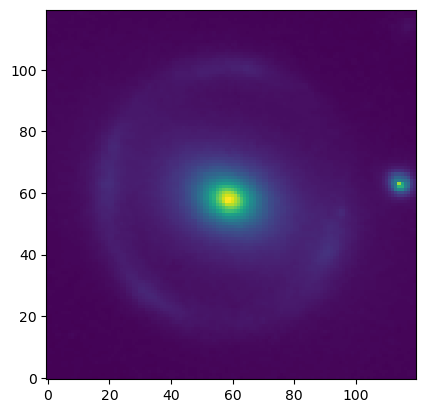

In [4]:
observed_img = np.load("desi165data/system65.npy")
observed_img = observed_img[15:135, 10:130]
plt.imshow(observed_img, cmap="viridis", origin='lower')
print(observed_img.shape)

In [5]:
kernel = np.load("desi165data/psf65.npy").astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=120, supersample=1, kernel=kernel)
n_max=6
sersic2=sersic
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic2.SersicEllipse(use_lstsq=True),sersic2.SersicEllipse(use_lstsq=True),sersic2.SersicEllipse(use_lstsq=True),sersic2.SersicEllipse(use_lstsq=True)], [sersic2.SersicEllipse(use_lstsq=True),shapelets.Shapelets(n_max=n_max, use_lstsq=True, interpolate=False)])
phys_model_forward = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic2.SersicEllipse(use_lstsq=False),sersic2.SersicEllipse(use_lstsq=False),sersic2.SersicEllipse(use_lstsq=False),sersic2.SersicEllipse(use_lstsq=False)], [shapelets.Shapelets(n_max=n_max, use_lstsq=False, interpolate=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
background_rms = 0.008230474 #background_rms from photutils.background
exp_time = 1197.699462
prob_model = BackwardProbModel(prior, jnp.array(observed_img), background_rms=background_rms, exp_time=exp_time)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [6]:
# opt = optax.adabelief(1e-2, b1=0.95, b2=0.99, nesterov=True)
# best, lps, chisq = model_seq.MAP(opt, seed=0, n_samples=100, num_steps=3000)

In [7]:
# norm = simple_norm(observed_img, "sqrt", percent=99.)
# physical = prob_model.bij.forward(list(best.T))
# print(physical)
# err_map = np.sqrt(background_rms**2 + observed_img/exp_time)
# simulated = lens_sim.lstsq_simulate(physical, jnp.array(observed_img), err_map)[0]
# plt.imshow(simulated, norm=norm, cmap="viridis", origin='lower')

In [8]:
# schedule_fn = optax.polynomial_schedule(init_value=1e-3, end_value=1e-6,
#                                         power=0.5, transition_steps=1000)
# opt = optax.adabelief(schedule_fn, b1=0.95, b2=0.99)
# qz, loss_hist = model_seq.SVI(best, opt, n_vi=1000, num_steps=1250, init_scales=1e-2)
# plt.plot(loss_hist)

In [9]:
qz = jnp.load("desi165data/qz.npz")
qz = tfd.MultivariateNormalTriL(loc=qz['loc'], scale_tril=qz['scale_tril'])

# mclmc_samples_prev = jnp.load('desi165data/mclmc_samples.npy')
# smp_prev = mclmc_samples_prev.reshape(-1,mclmc_samples_prev.shape[-1])
# sample_cov = jnp.cov(smp_prev, rowvar=False)
# qz_true = tfd.MultivariateNormalFullCovariance(loc=jnp.mean(smp_prev,axis=0), covariance_matrix=sample_cov)
# qz=qz_true

In [24]:
import mclmc_alt
import importlib
importlib.reload(mclmc_alt)
from mclmc_alt import MCLMC_JIT

num_burnin_steps = 2000
num_results=2000
frac_tune1=0.2 #* initial step size tuning
frac_tune2=0.6 #* Used for mass matrix adaptation
frac_tune3=0.2 #! Tuning L. ~10 effective samples are needed for this to be accurate

debug_hist = MCLMC_JIT(
    model_seq, qz, 
    n_hmc=8, num_burnin_steps=num_burnin_steps, num_results=num_results, 
    desired_energy_variance=5e-4, frac_tune1=frac_tune1, frac_tune2=frac_tune2, frac_tune3=frac_tune3,
    seed=0, debug_output=True, step_size_adapt_use_psmile=False, use_shard_map=True, 
    windowed_mass_matrix=False,
)

Sampling took 51.347896122024395 s


In [25]:
mclmc_samples = debug_hist.position[:, -num_results:, :]
dim = mclmc_samples.shape[-1]
samples = mclmc_samples[:, :,:].reshape(-1, dim)

final_cov = jnp.cov(samples.T)

/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


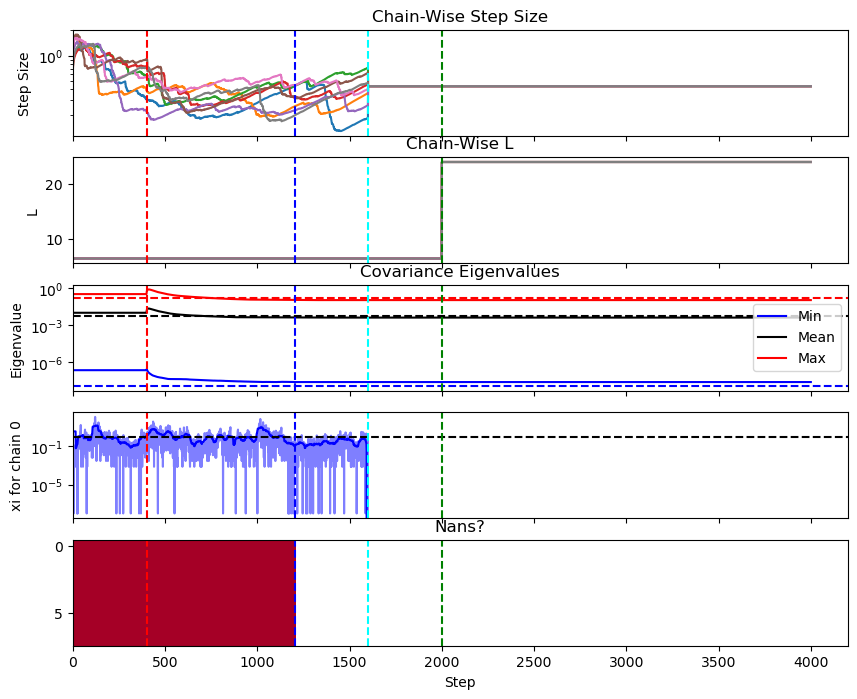

In [26]:
stage1 = int(frac_tune1*num_burnin_steps)
stage2 = int((frac_tune1+0.67*frac_tune2)*num_burnin_steps)
stage25 = int((frac_tune1+frac_tune2)*num_burnin_steps)
stage3 = int((frac_tune1+frac_tune2+frac_tune3)*num_burnin_steps)

fig, axs = plt.subplots(5, 1, sharex=True)
ax1, ax2, ax3, ax4, ax_last =axs
fig.set_size_inches(10, 8)
ax1.plot(debug_hist.step_size.T)
ax1.set_title("Chain-Wise Step Size")
ax1.set_ylabel("Step Size")
# ax1.set_ylim(top=10)
ax1.set_yscale('log')

ax2.plot(debug_hist.L.T)
ax2.set_title("Chain-Wise L")
ax2.set_ylabel("L")
# ax2.set_ylim(top=20)



inverse_mass_matrix_hist = debug_hist.inverse_mass_matrix[0]
vmapped_eigval = jax.vmap(lambda x: jnp.linalg.eig(x)[0])
mass_mat_eigval = vmapped_eigval(inverse_mass_matrix_hist)
min_eigval = jnp.min(mass_mat_eigval, axis=1)
max_eigval = jnp.max(mass_mat_eigval, axis=1)
mean_eigval = jnp.mean(mass_mat_eigval, axis=1)

final_eigvals = jnp.real(jnp.linalg.eig(final_cov)[0])
min_eigval_final = jnp.min(final_eigvals)
max_eigval_final = jnp.max(final_eigvals)
mean_eigval_final = jnp.mean(final_eigvals)

ax3.plot(min_eigval, label='Min', color='blue')
ax3.axhline(min_eigval_final, color='blue', linestyle='--')
ax3.plot(mean_eigval, label='Mean', color='black')
ax3.axhline(mean_eigval_final, color='black', linestyle='--')
ax3.plot(max_eigval, label='Max', color='red')
ax3.axhline(max_eigval_final, color='red', linestyle='--')



ax3.legend()
ax3.set_title("Covariance Eigenvalues")
ax3.set_yscale('log')
ax3.set_ylabel("Eigenvalue")



smooth_kernel_size = 30
kernel = np.ones(smooth_kernel_size) / smooth_kernel_size
xi_chain = debug_hist.xi[8]
xi_smoothed = np.convolve(xi_chain, kernel, mode='same')
ax4.plot(xi_chain, alpha=0.5, color='blue')
ax4.plot(xi_smoothed, alpha=1.0, color='blue')
ax4.set_yscale('log')
ax4.set_ylabel("xi for chain 0")
ax4.axhline(1.0, color='black', linestyle='--')

ax_last.set_xlabel("Step")

ax_last.set_title("Nans?")
ax_last.imshow(debug_hist.nonan[:,:stage2], aspect='auto', interpolation='none', cmap='RdYlGn')

for ax in axs:
    ax.axvline(stage1, color='red', linestyle='--')
    ax.axvline(stage2, color='blue', linestyle='--')
    ax.axvline(stage25, color='cyan', linestyle='--')
    ax.axvline(stage3, color='green', linestyle='--')

    # ax.set_xlim(right=stage3)


plt.show()

In [19]:
import laps
importlib.reload(laps)
from laps import LAPS_JIT
debug_hist, carry = LAPS_JIT(
    model_seq,
    qz,
    n_hmc=64,
    num_unadjusted_steps=2000,
    num_adjusted_steps=100,
    num_results=500,
    adapt_mass_matrix=True,
    debug_output=True,
    # alpha=jnp.float32(20.0),
    seed=0,
    # switch_threshold=jnp.float32(0.01),
    # mass_matrix_trigger_threshold=jnp.float32(0.2),
)

2026-03-25 17:37:44.528366: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-25 17:37:48.616043: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-25 17:37:48.616288: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-25 17:37:48.616322: W external/xla/xla/service/gpu/au

Sampling took 598.4849977939157 s


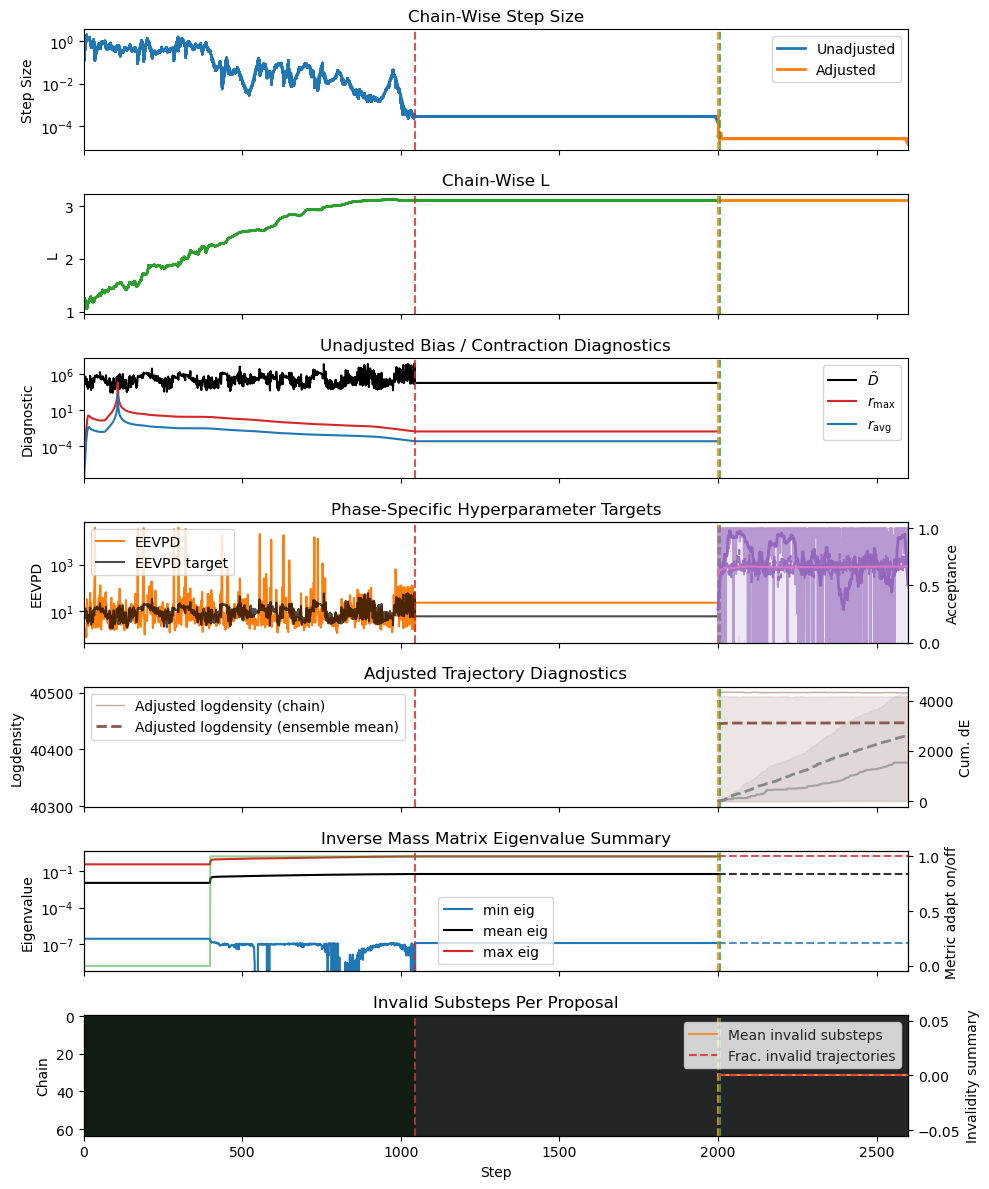

In [20]:
laps_samples = debug_hist[2].position
import laps
importlib.reload(laps)
from laps import plot_laps_diagnostics

fig, axs = plot_laps_diagnostics(debug_hist, carry=carry)
plt.show()

In [27]:
print(jnp.max(blackjax.diagnostics.potential_scale_reduction(mclmc_samples, chain_axis=0, sample_axis=1)))
print(blackjax.diagnostics.effective_sample_size(mclmc_samples, chain_axis=0, sample_axis=1))

# print(jnp.max(blackjax.diagnostics.potential_scale_reduction(laps_samples, chain_axis=0, sample_axis=1)))
# print(blackjax.diagnostics.effective_sample_size(laps_samples, chain_axis=0, sample_axis=1))

1.0451409
[415.7787  431.64612 448.49042 461.0384  386.11444 467.70178 440.05783
 476.9177  276.95108 350.05957 177.2221  316.13303 381.62924 201.87749
 215.38202 187.56154 288.782   346.39154 355.03406 212.9005  424.5845
 426.65698 464.77444 434.95203 446.9117  438.92038 386.28464 475.47247
 467.83524 464.59998 450.361   522.5527  258.27005 438.1254  445.02292
 346.94168 337.95074 207.97296 340.51898 486.6987  481.99274]


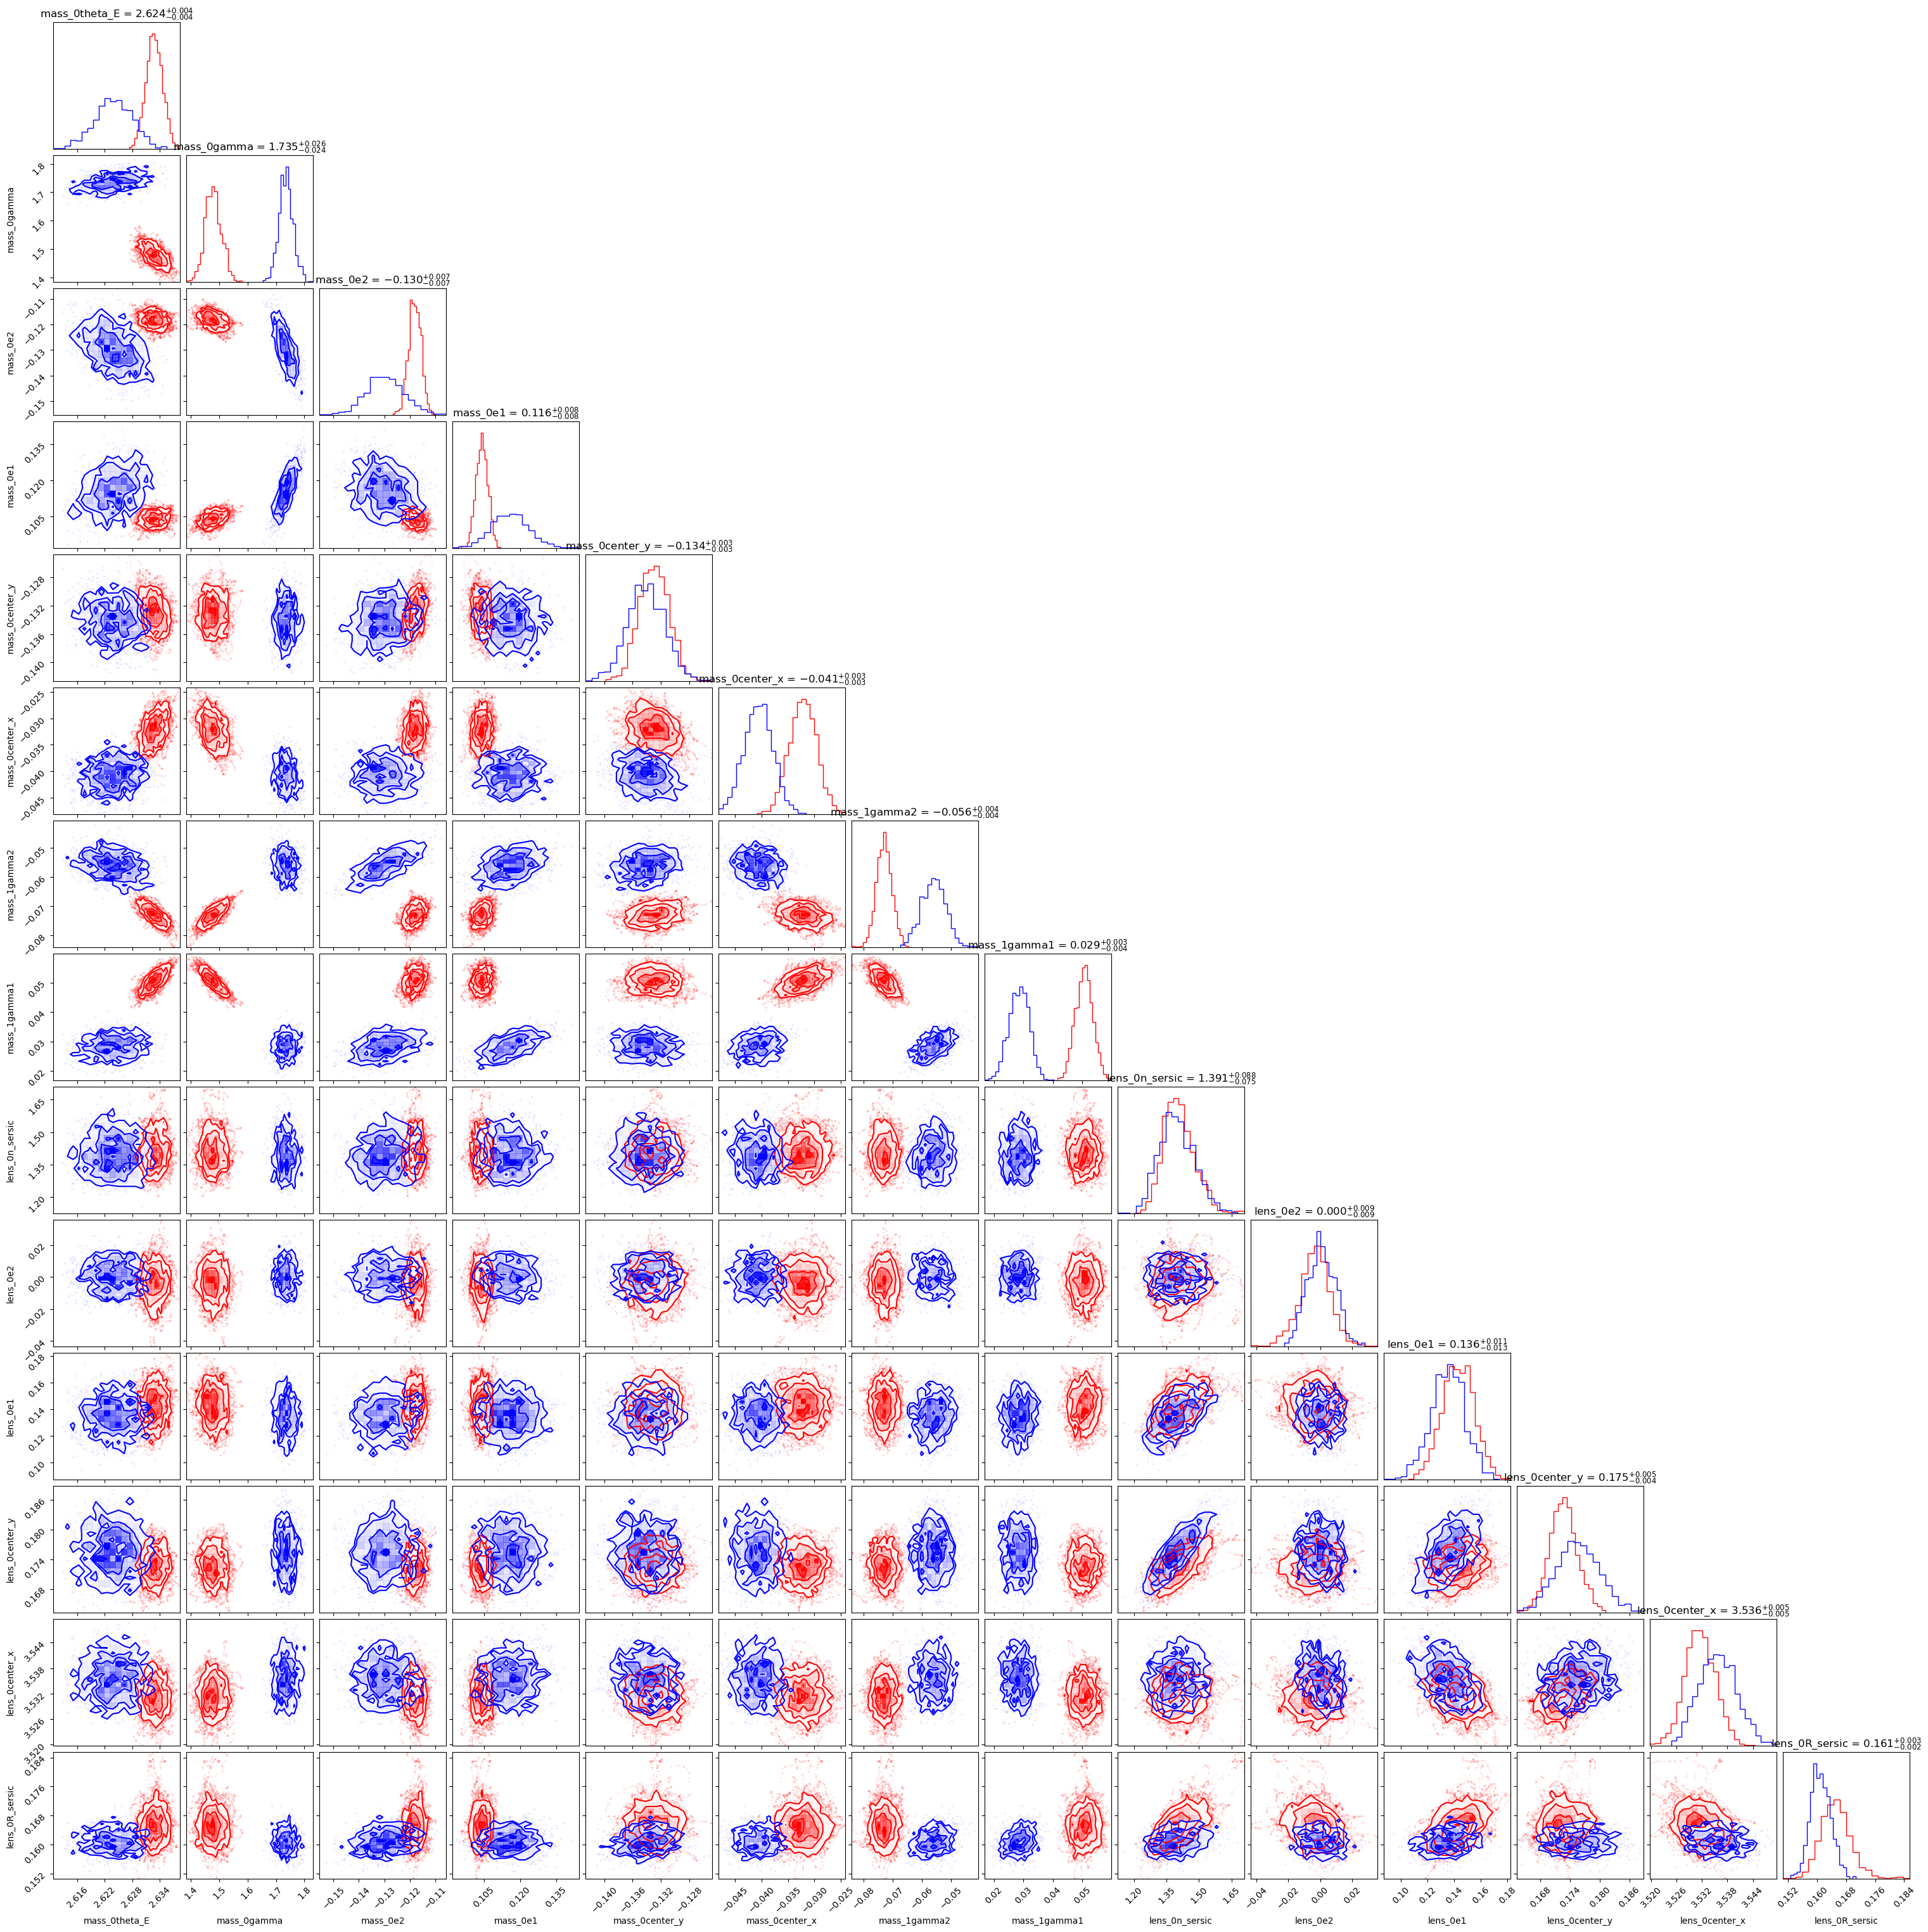

In [28]:
dim = mclmc_samples.shape[-1]
run_key = jax.random.key(0)
samples = mclmc_samples[:, :,:].reshape(-1, dim) 
MCMC_x = prob_model.bij.forward(list(samples.T))

# laps_smp = laps_samples[:, :,:].reshape(-1, dim) 
# LAPS_x = prob_model.bij.forward(list(laps_smp.T))

# adapt_cov = debug_hist.inverse_mass_matrix[0,-1]
# adapt_qz = tfd.MultivariateNormalFullCovariance(loc=jnp.mean(samples, axis=0), covariance_matrix=adapt_cov)
# adapt_qz_samples = adapt_qz.sample((1000,), run_key)
# adapt_qz_x = prob_model.bij.forward(list(adapt_qz_samples.T))

SVI_samples = qz.sample((1000,), run_key)
SVI_x = prob_model.bij.forward(list(SVI_samples.T))

# HMC_1chain_x = prob_model.bij.forward(list(results['HMC'].HMC_samples_z[0, 11, -40000:].T))

plot_params = cornerplot_labels(MCMC_x)[:14]

# hmc_x = prob_model.bij.forward(list(hmc_samples.reshape(-1, dim).T))

# n_samp = hmc_samples.shape[0]*hmc_samples.shape[1]
# rand_idx = np.random.choice(np.arange(n_samp), size=(10000,), replace=False)

# fig = cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx], hmc_x), color='black',plot_params=plot_params)

n_samp_MCMC = MCMC_x[0][0]['e1'].shape[0]
rand_idx_MCMC = np.random.choice(np.arange(n_samp_MCMC), size=(10000,), replace=True)
fig = cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx_MCMC], MCMC_x), color='red',plot_params=plot_params)

# n_samp_LAPS = LAPS_x[0][0]['e1'].shape[0]
# rand_idx_LAPS = np.random.choice(np.arange(n_samp_LAPS), size=(10000,), replace=True)
# cornerplot_posterior(LAPS_x, fig=fig, color='orange', plot_params=plot_params)


cornerplot_posterior(SVI_x, fig=fig, color='blue', plot_params=plot_params)
# cornerplot_posterior(adapt_qz_x, fig=fig, color='purple', plot_params=plot_params)
# cornerplot_posterior(mclmc_results_100sys.HMC_samples, fig=fig, color='purple', plot_params=plot_params)
# cornerplot_posterior(HMC_1chain_x, fig=fig, color='green', plot_params=plot_params)

plt.show()